In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [16]:
df = pd.read_csv("retail_large_dataset.csv")

df.shape
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.561830,30164.526720,2.501790,15.009890,64165.723382,5.505540
std,13.852439,17139.679807,1.120058,8.953296,49969.280150,2.872868
min,18.000000,500.000000,1.000000,0.000000,357.000000,1.000000
25%,30.000000,15375.000000,1.000000,7.000000,24705.000000,3.000000
50%,42.000000,30148.000000,3.000000,15.000000,49752.390000,5.000000
75%,54.000000,44957.000000,4.000000,23.000000,94046.070000,8.000000
max,65.000000,59998.000000,4.000000,30.000000,239980.000000,10.000000


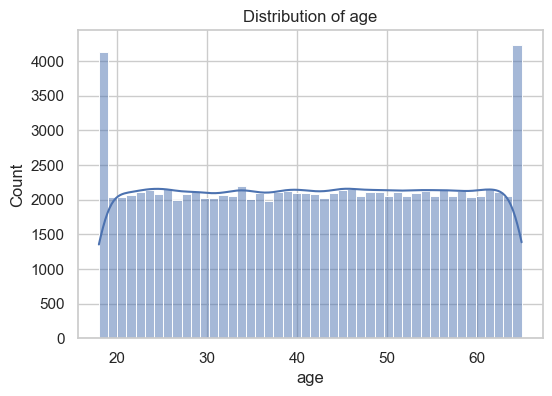

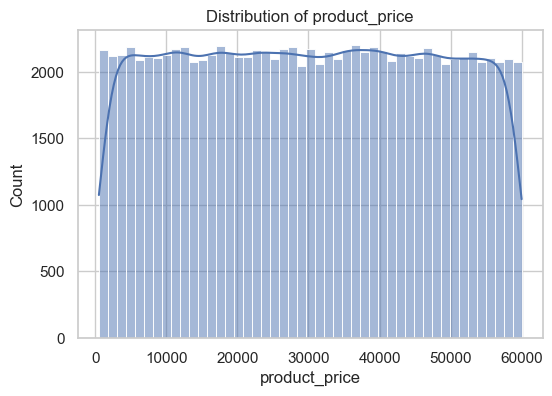

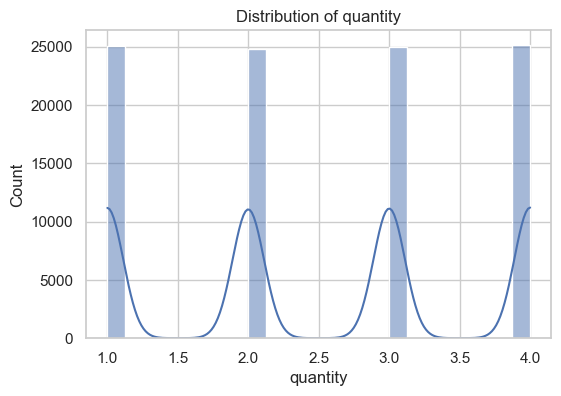

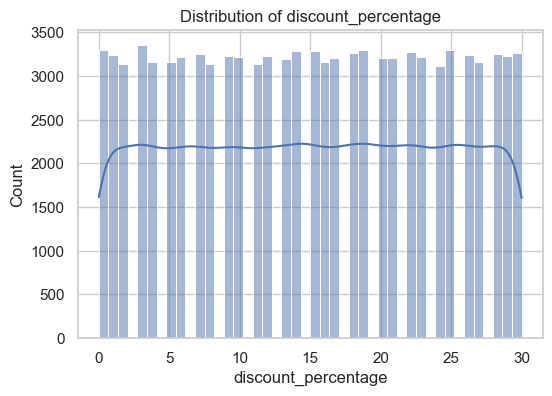

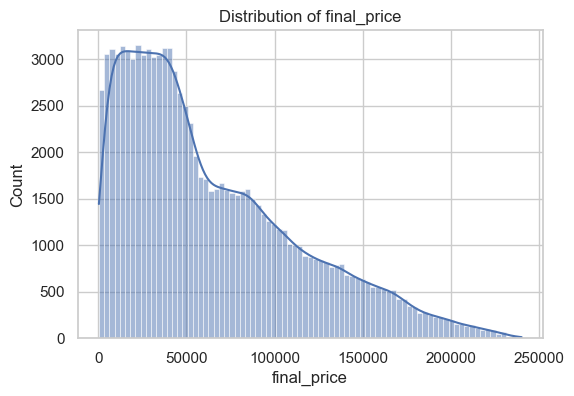

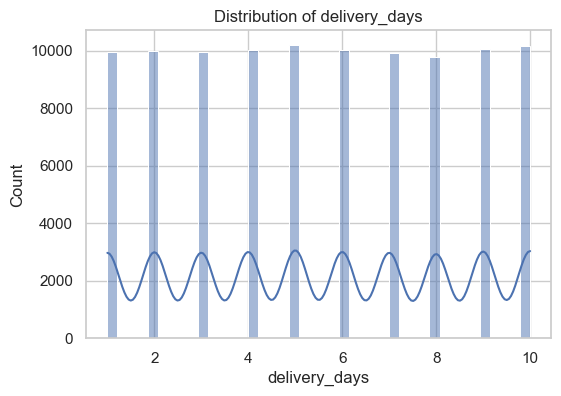

In [18]:
num_cols = ['age','product_price','quantity','discount_percentage','final_price','delivery_days']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

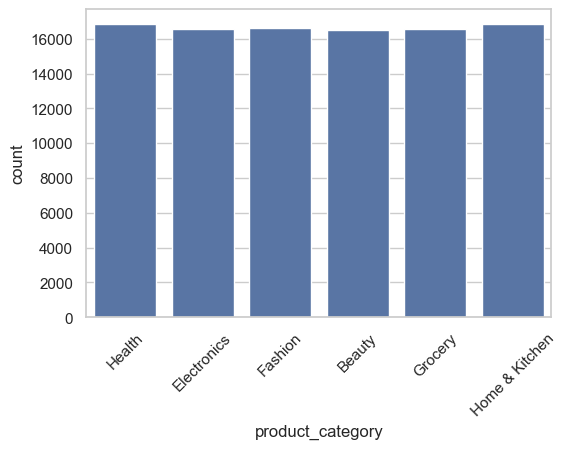

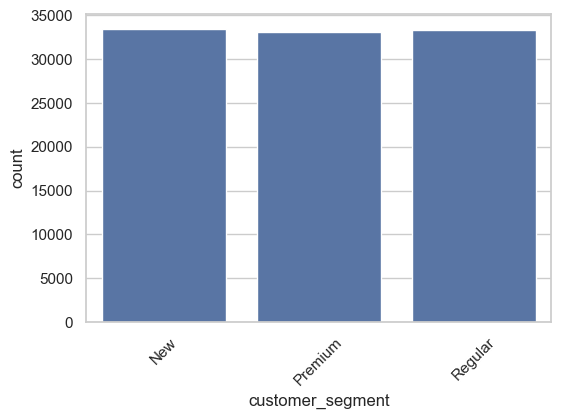

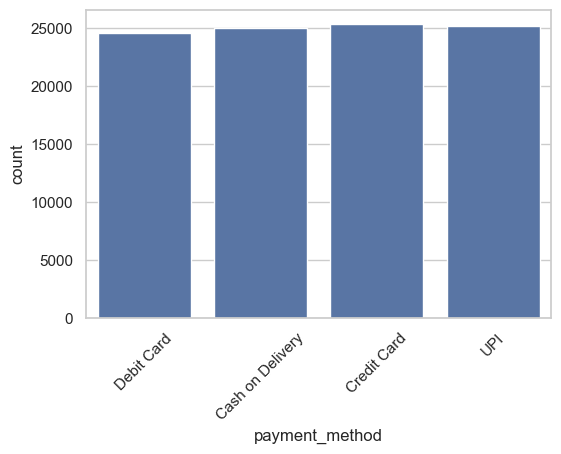

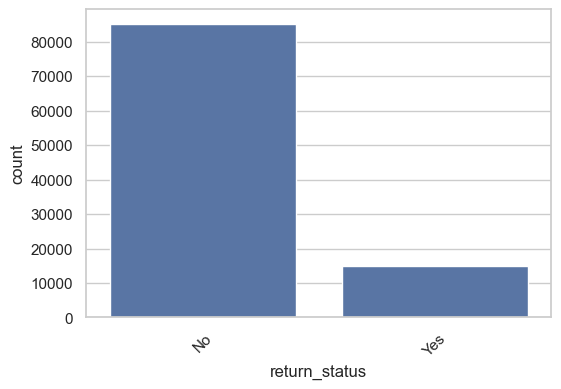

In [19]:
cat_cols = ['product_category','customer_segment','payment_method','return_status']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.show()

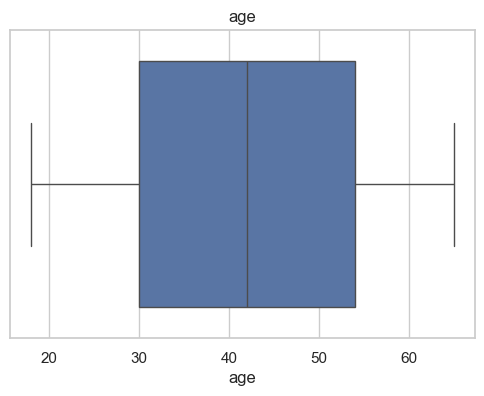

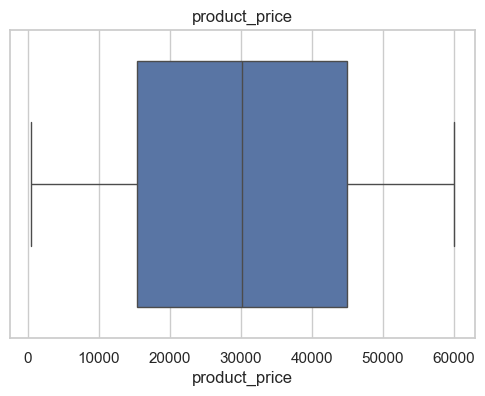

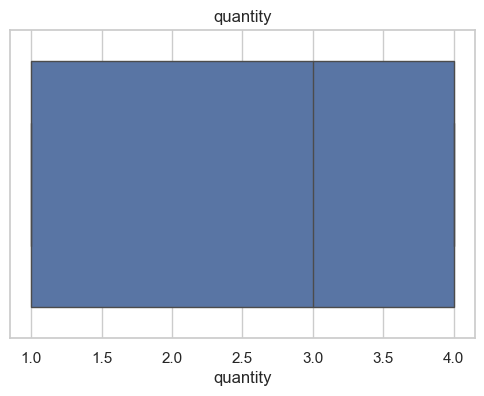

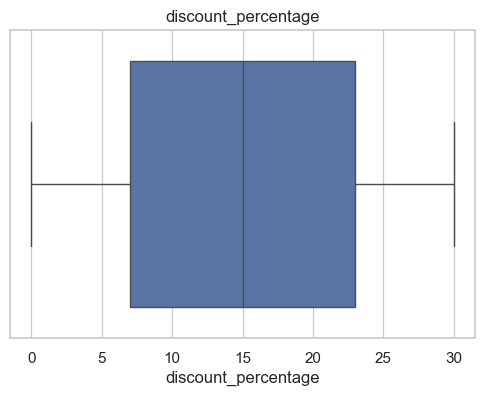

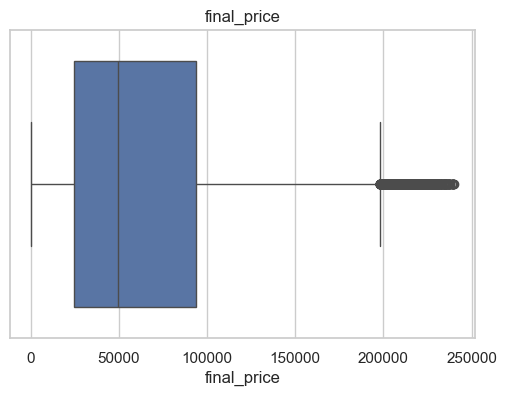

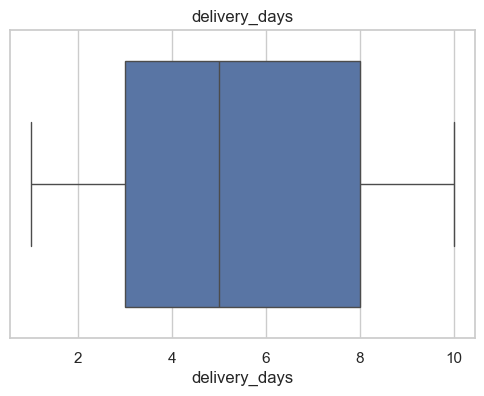

In [20]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

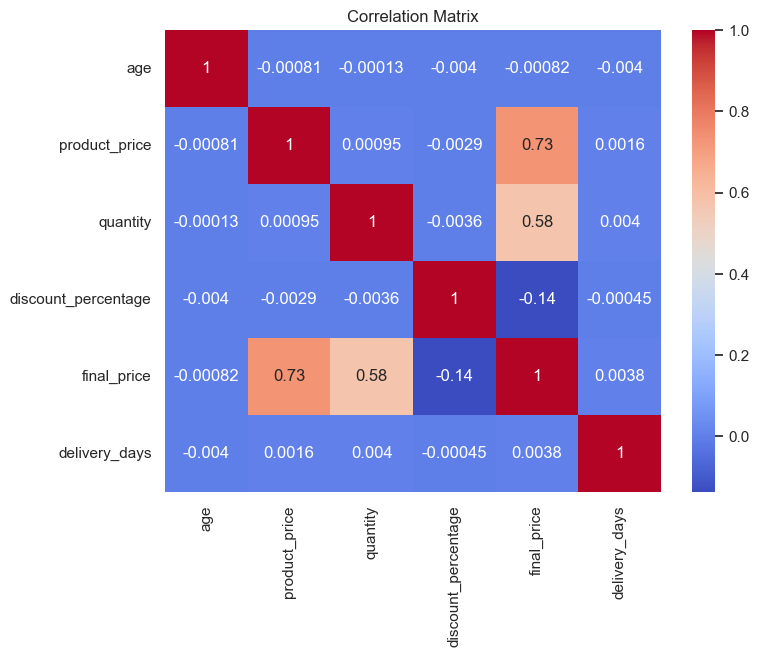

In [21]:
corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

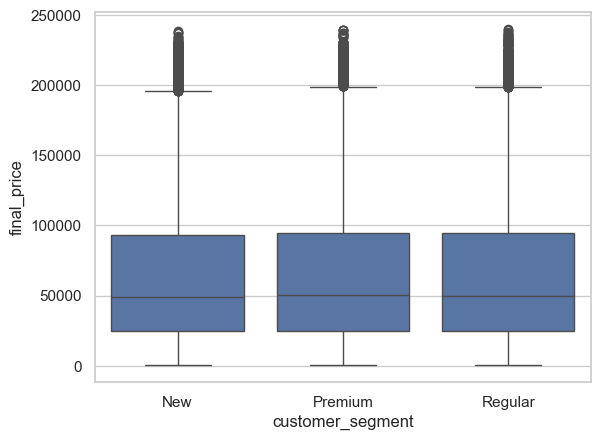

In [22]:
sns.boxplot(x='customer_segment', y='final_price', data=df)
plt.show()

In [23]:
df.groupby('product_category')['final_price'].sum().sort_values(ascending=False)

product_category
Home & Kitchen    1.092431e+09
Health            1.073630e+09
Electronics       1.066329e+09
Grocery           1.063577e+09
Fashion           1.063268e+09
Beauty            1.057336e+09
Name: final_price, dtype: float64

In [24]:
df['return_status'].value_counts(normalize=True)

return_status
No     0.85189
Yes    0.14811
Name: proportion, dtype: float64

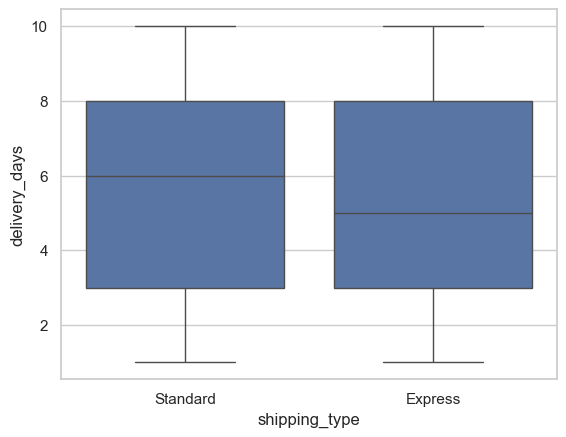

In [25]:
sns.boxplot(x='shipping_type', y='delivery_days', data=df)
plt.show()

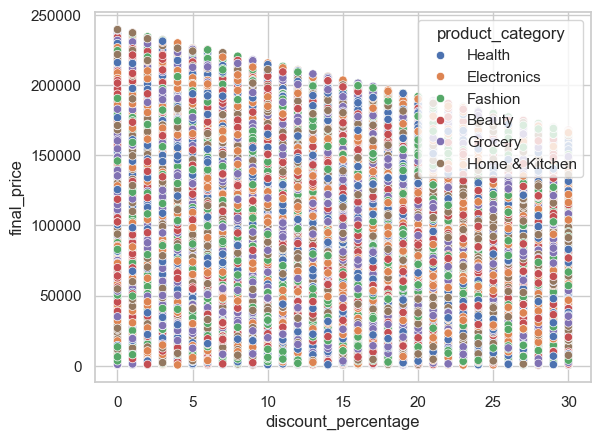

In [26]:
sns.scatterplot(
    x='discount_percentage',
    y='final_price',
    hue='product_category',
    data=df
)
plt.show()

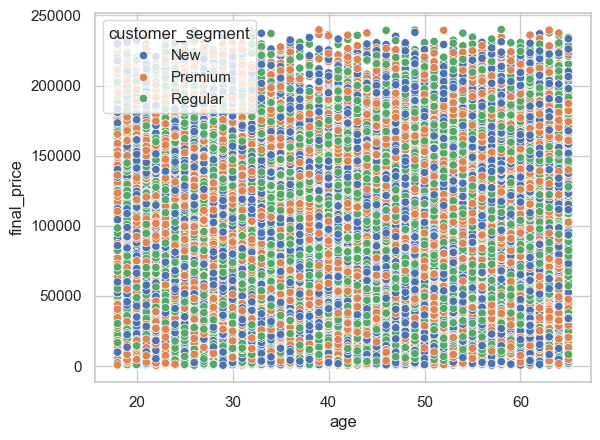

In [27]:
sns.scatterplot(
    x='age',
    y='final_price',
    hue='customer_segment',
    data=df
)
plt.show()

In [28]:
df[num_cols].skew()
df[num_cols].kurt()

age                   -1.201172
product_price         -1.195106
quantity              -1.364612
discount_percentage   -1.201628
final_price            0.169047
delivery_days         -1.221514
dtype: float64